# Notebook 3: Evaluation
100 questions, metrics: Hit@3, ROUGE-L, Latency

In [2]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient
from transformers import pipeline
from tqdm import tqdm

/Users/arystankamalov/Desktop/Minecraft_RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds = load_dataset("naklecha/minecraft-question-answer-700k", split="train")

eval_set = []
for i in range(5000, 5100):
    eval_set.append({"question": ds[i]["question"], "answer": ds[i]["answer"]})

print(len(eval_set), "eval questions")

100 eval questions


In [4]:
client = PersistentClient(path="./db")

emb_minilm = SentenceTransformer("all-MiniLM-L6-v2")
emb_mpnet  = SentenceTransformer("all-mpnet-base-v2")

col_minilm = client.get_collection("minecraft_minilm")
col_mpnet  = client.get_collection("minecraft_mpnet")

llm_qwen = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", device=-1)
llm_tiny = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-360M-Instruct", device=-1)

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5525.46it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5559.44it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1699.31it/s]


In [5]:
prompt_minimal = """Context: {context}
Question: {question}
Answer:"""

prompt_detailed = """You are a Minecraft expert assistant.
Use ONLY the context below to answer the question.
If the answer is not in the context, say "I don't know."

Context:
{context}

Question: {question}
Answer:"""

prompt_cot = """You are a Minecraft expert.
Think step by step using the context provided.

Context:
{context}

Question: {question}
Let's think step by step:"""

In [6]:
def retrieve(collection, emb_model, question, top_k=3):
    query_embedding = emb_model.encode([question], normalize_embeddings=True).tolist()
    results = collection.query(query_embeddings=query_embedding, n_results=top_k)
    docs = results['documents'][0]
    context = "\n".join(docs)
    return context, docs

def generate(llm, prompt):
    out = llm(prompt, max_new_tokens=150, do_sample=False, repetition_penalty=1.1, truncation=True)
    return out[0]["generated_text"][len(prompt):].strip()

def hit_at_3(docs, ground_truth):
    for doc in docs:
        score = scorer.score(doc, ground_truth)["rougeL"].fmeasure
        if score > 0.3:
            return 1
    return 0

def rouge_l(prediction, reference):
    return scorer.score(prediction, reference)["rougeL"].fmeasure

In [ ]:
embedding_options = [
    ("minilm", emb_minilm, col_minilm),
    ("mpnet",  emb_mpnet,  col_mpnet),
]

llm_options = [
    ("qwen",    llm_qwen),
    ("smollm",  llm_tiny),
]

prompt_options = [
    ("minimal",  prompt_minimal),
    ("detailed", prompt_detailed),
    ("cot",      prompt_cot),
]

eval_results = []

for emb_name, emb_model, col in embedding_options:
    for llm_name, llm in llm_options:
        for prompt_name, prompt_template in prompt_options:

            exp_name = f"{emb_name}+{llm_name}+{prompt_name}"
            print("Evaluating:", exp_name)

            hits, rouges, latencies = [], [], []

            for sample in tqdm(eval_set):
                question = sample["question"]
                ground_truth = sample["answer"]

                t0 = time.time()
                context, docs = retrieve(col, emb_model, question)
                prompt = prompt_template.format(context=context, question=question)
                answer = generate(llm, prompt)
                latency = time.time() - t0

                hits.append(hit_at_3(docs, ground_truth))
                rouges.append(rouge_l(answer, ground_truth))
                latencies.append(latency)

            eval_results.append({
                "exp_name": exp_name,
                "embedding": emb_name,
                "llm":llm_name,
                "prompt": prompt_name,
                "hit_at_3": float(np.mean(hits)),
                "rouge_l": float(np.mean(rouges)),
                "avg_latency":float(np.mean(latencies)),
            })
            print(f"hit@3={np.mean(hits):.3f} rouge-l={np.mean(rouges):.3f} latency={np.mean(latencies):.2f}s")

import os
os.makedirs("results", exist_ok=True)
with open("results/evaluation.json", "w") as f:
    json.dump(eval_results, f, indent=2)
print("saved!")

Evaluating: minilm+qwen+minimal


  0%|          | 0/100 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 100/100 [12:13<00:00,  7.34s/it]


  hit@3=0.570  rouge-l=0.226  latency=7.33s
Evaluating: minilm+qwen+detailed


100%|██████████| 100/100 [10:42<00:00,  6.43s/it]


  hit@3=0.570  rouge-l=0.234  latency=6.42s
Evaluating: minilm+qwen+cot


...

  hit@3=0.550  rouge-l=0.184  latency=3.17s
Evaluating: mpnet+smollm+detailed


100%|██████████| 100/100 [04:28<00:00,  2.68s/it]


  hit@3=0.550  rouge-l=0.043  latency=2.68s
Evaluating: mpnet+smollm+cot


100%|██████████| 100/100 [06:32<00:00,  3.93s/it]

  hit@3=0.550  rouge-l=0.042  latency=3.92s
saved!


In [ ]:
best = max(eval_results, key=lambda x: x["rouge_l"])
print("Best:", best["exp_name"])

best_emb_name, best_emb_model, best_col = next(e for e in embedding_options if e[0] == best["embedding"])
best_llm_name, best_llm = next(l for l in llm_options if l[0] == best["llm"])
best_prompt_name, best_prompt_template = next(p for p in prompt_options if p[0] == best["prompt"])

topk_rouge = []
for top_k in [1, 3, 5]:
    rouges = []
    for sample in tqdm(eval_set, desc=f"top_k={top_k}"):
        context, docs = retrieve(best_col, best_emb_model, sample["question"], top_k)
        prompt = best_prompt_template.format(context=context, question=sample["question"])
        answer = generate(best_llm, prompt)
        rouges.append(rouge_l(answer, sample["answer"]))
    topk_rouge.append(np.mean(rouges))
    print(f"top_k={top_k}  rouge-l={np.mean(rouges):.3f}")

Best: minilm+qwen+detailed


top_k=1: 100%|██████████| 100/100 [09:22<00:00,  5.63s/it]


top_k=1  rouge-l=0.224


top_k=3: 100%|██████████| 100/100 [11:24<00:00,  6.85s/it]


top_k=3  rouge-l=0.234


top_k=5: 100%|██████████| 100/100 [15:01<00:00,  9.01s/it]

top_k=5  rouge-l=0.212


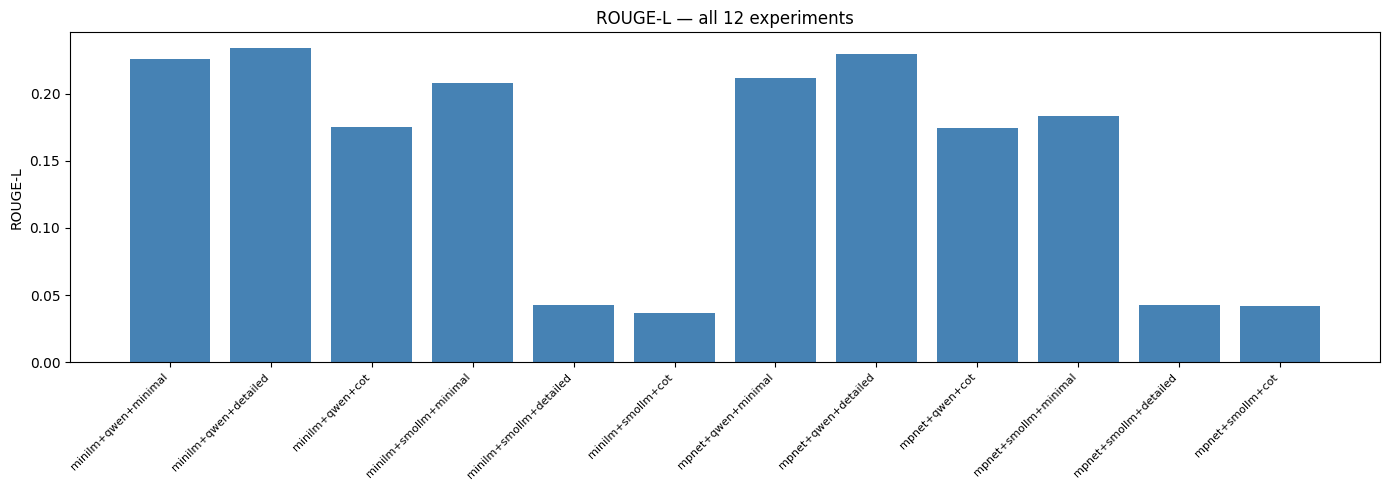

In [ ]:
names = [r["exp_name"] for r in eval_results]
rouges = [r["rouge_l"]  for r in eval_results]

plt.figure(figsize=(14, 5))
plt.bar(names, rouges, color="steelblue")
plt.title("ROUGE-L — all 12 experiments")
plt.ylabel("ROUGE-L")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("results/rouge_l.png")
plt.show()

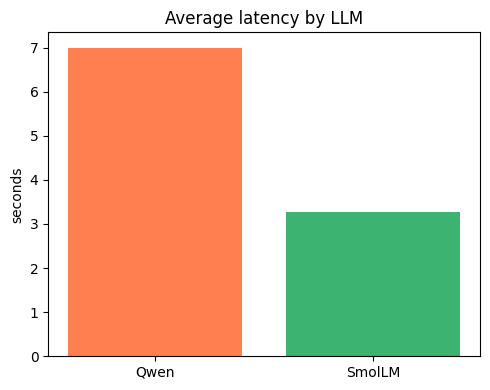

In [ ]:
qwen_lat = np.mean([r["avg_latency"] for r in eval_results if r["llm"] == "qwen"])
tiny_lat = np.mean([r["avg_latency"] for r in eval_results if r["llm"] == "smollm"])

plt.figure(figsize=(5, 4))
plt.bar(["Qwen", "SmolLM"], [qwen_lat, tiny_lat], color=["coral", "mediumseagreen"])
plt.title("Average latency by LLM")
plt.ylabel("seconds")
plt.tight_layout()
plt.savefig("results/latency.png")
plt.show()

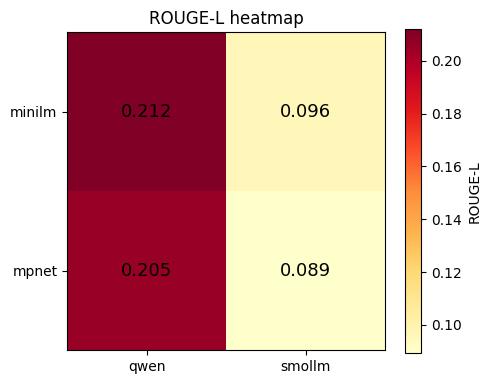

In [ ]:
matrix = np.zeros((2, 2))
emb_names =["minilm", "mpnet"]
llm_names =["qwen", "smollm"]

for i, emb in enumerate(emb_names):
    for j, llm in enumerate(llm_names):
        vals = [r["rouge_l"] for r in eval_results if r["embedding"] == emb and r["llm"] == llm]
        matrix[i][j] = np.mean(vals)

plt.figure(figsize=(5, 4))
plt.imshow(matrix, cmap="YlOrRd")
plt.colorbar(label="ROUGE-L")
plt.xticks([0, 1], llm_names)
plt.yticks([0, 1], emb_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{matrix[i][j]:.3f}", ha="center", va="center", fontsize=13)
plt.title("ROUGE-L heatmap")
plt.tight_layout()
plt.savefig("results/heatmap.png")
plt.show()

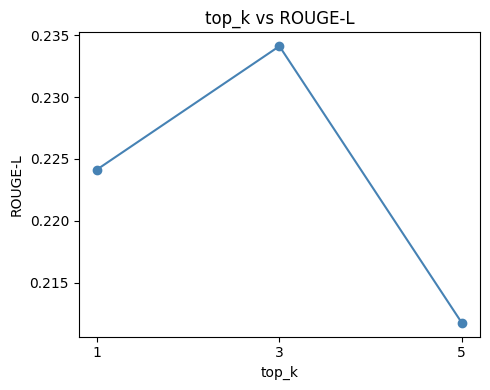

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot([1, 3, 5], topk_rouge, marker="o", color="steelblue")
plt.title("top_k vs ROUGE-L")
plt.xlabel("top_k")
plt.ylabel("ROUGE-L")
plt.xticks([1, 3, 5])
plt.tight_layout()
plt.savefig("results/topk.png")
plt.show()